# Wafer Defect Detection - Data Exploration

This notebook explores the WM-811K (LSWMD) semiconductor wafer dataset for defect pattern classification.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from data import WaferDataProcessor

# Handle different matplotlib/seaborn versions
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        pass
        
sns.set_palette("husl")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## 1. Load Configuration and Data

In [2]:
with open('../configs/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

processor = WaferDataProcessor(config)
df = processor.load_data()

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Loading data from /Users/nishanthegde/Desktop/wafer-defects-detection/data/LSWMD.pkl...
Initial data shape: (811457, 6)
Columns: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']
Data shape after cleaning: (172950, 8)
Dataset shape: (172950, 8)

Columns: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType', 'failureType_clean', 'label']


In [3]:
df.head()

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType,failureType_clean,label
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]],none,8
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]],none,8
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]],none,8
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]],none,8
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]],none,8


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 172950 entries, 0 to 811454
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   waferMap           172950 non-null  object 
 1   dieSize            172950 non-null  float64
 2   lotName            172950 non-null  object 
 3   waferIndex         172950 non-null  float64
 4   trianTestLabel     172950 non-null  object 
 5   failureType        172950 non-null  object 
 6   failureType_clean  172950 non-null  object 
 7   label              172950 non-null  int64  
dtypes: float64(2), int64(1), object(5)
memory usage: 11.9+ MB


## 2. Class Distribution Analysis

In [5]:
class_distribution = processor.get_class_distribution(df)

print("Class Distribution:")
print("="*50)
for class_name, count in class_distribution.items():
    percentage = (count / len(df)) * 100
    print(f"{class_name:15s}: {count:6d} ({percentage:5.2f}%)")

Class Distribution:
Center         :   4294 ( 2.48%)
Donut          :    555 ( 0.32%)
Edge-Loc       :   5189 ( 3.00%)
Edge-Ring      :   9680 ( 5.60%)
Loc            :   3593 ( 2.08%)
Near-full      :    149 ( 0.09%)
Random         :    866 ( 0.50%)
Scratch        :   1193 ( 0.69%)
none           : 147431 (85.24%)


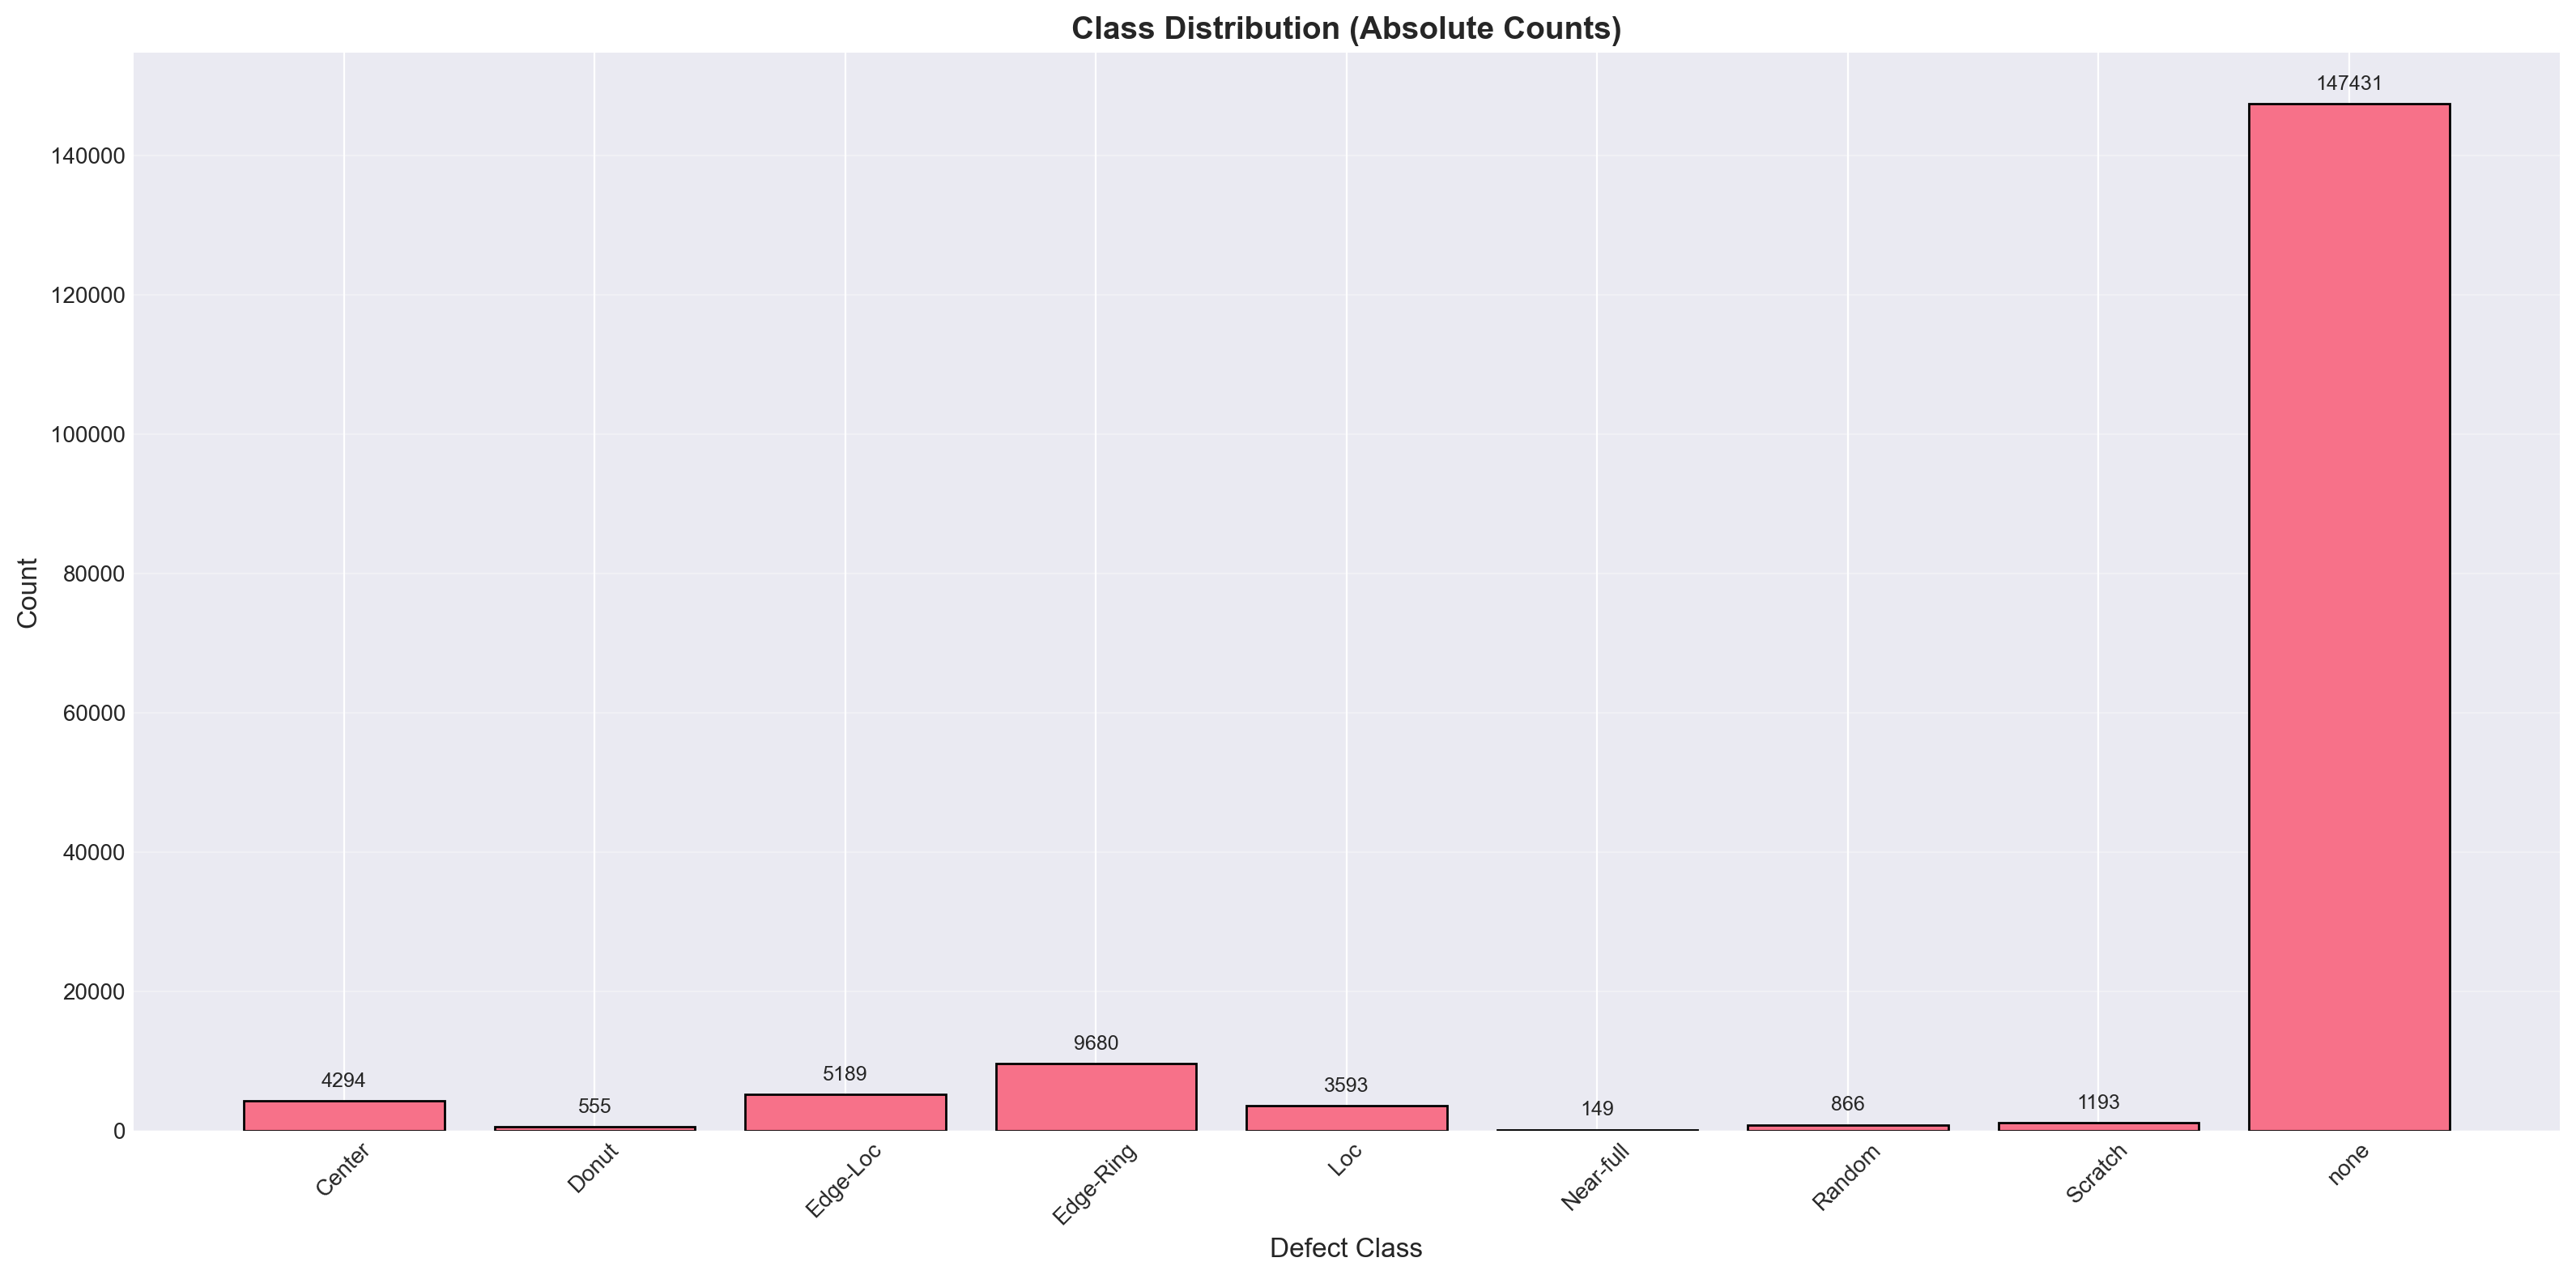

In [14]:
fig, ax = plt.subplots(figsize=(16, 8))

classes = list(class_distribution.keys())
counts = list(class_distribution.values())

ax.bar(classes, counts, edgecolor='black')
ax.set_xlabel('Defect Class', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Class Distribution (Absolute Counts)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

for i, (cls, count) in enumerate(zip(classes, counts)):
    ax.text(i, count + max(counts) * 0.01, str(count), 
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/visualizations/class_distribution.png',
            dpi=300, bbox_inches='tight')
plt.show()

## 3. Wafer Map Dimensions Analysis

In [15]:
wafer_heights = []
wafer_widths = []
aspect_ratios = []

for idx in range(min(10000, len(df))):
    wafer_map = df.iloc[idx]['waferMap']
    if wafer_map is not None and len(wafer_map) > 0:
        height = len(wafer_map)
        width = len(wafer_map[0]) if height > 0 else 0
        
        if height > 0 and width > 0:
            wafer_heights.append(height)
            wafer_widths.append(width)
            aspect_ratios.append(height / width)

print(f"Analyzed {len(wafer_heights)} wafer maps")
print(f"\nHeight - Min: {min(wafer_heights)}, Max: {max(wafer_heights)}, Mean: {np.mean(wafer_heights):.2f}")
print(f"Width  - Min: {min(wafer_widths)}, Max: {max(wafer_widths)}, Mean: {np.mean(wafer_widths):.2f}")
print(f"Aspect Ratio - Min: {min(aspect_ratios):.2f}, Max: {max(aspect_ratios):.2f}, Mean: {np.mean(aspect_ratios):.2f}")

Analyzed 10000 wafer maps

Height - Min: 22, Max: 137, Mean: 32.78
Width  - Min: 24, Max: 116, Mean: 31.76
Aspect Ratio - Min: 0.63, Max: 1.94, Mean: 1.03


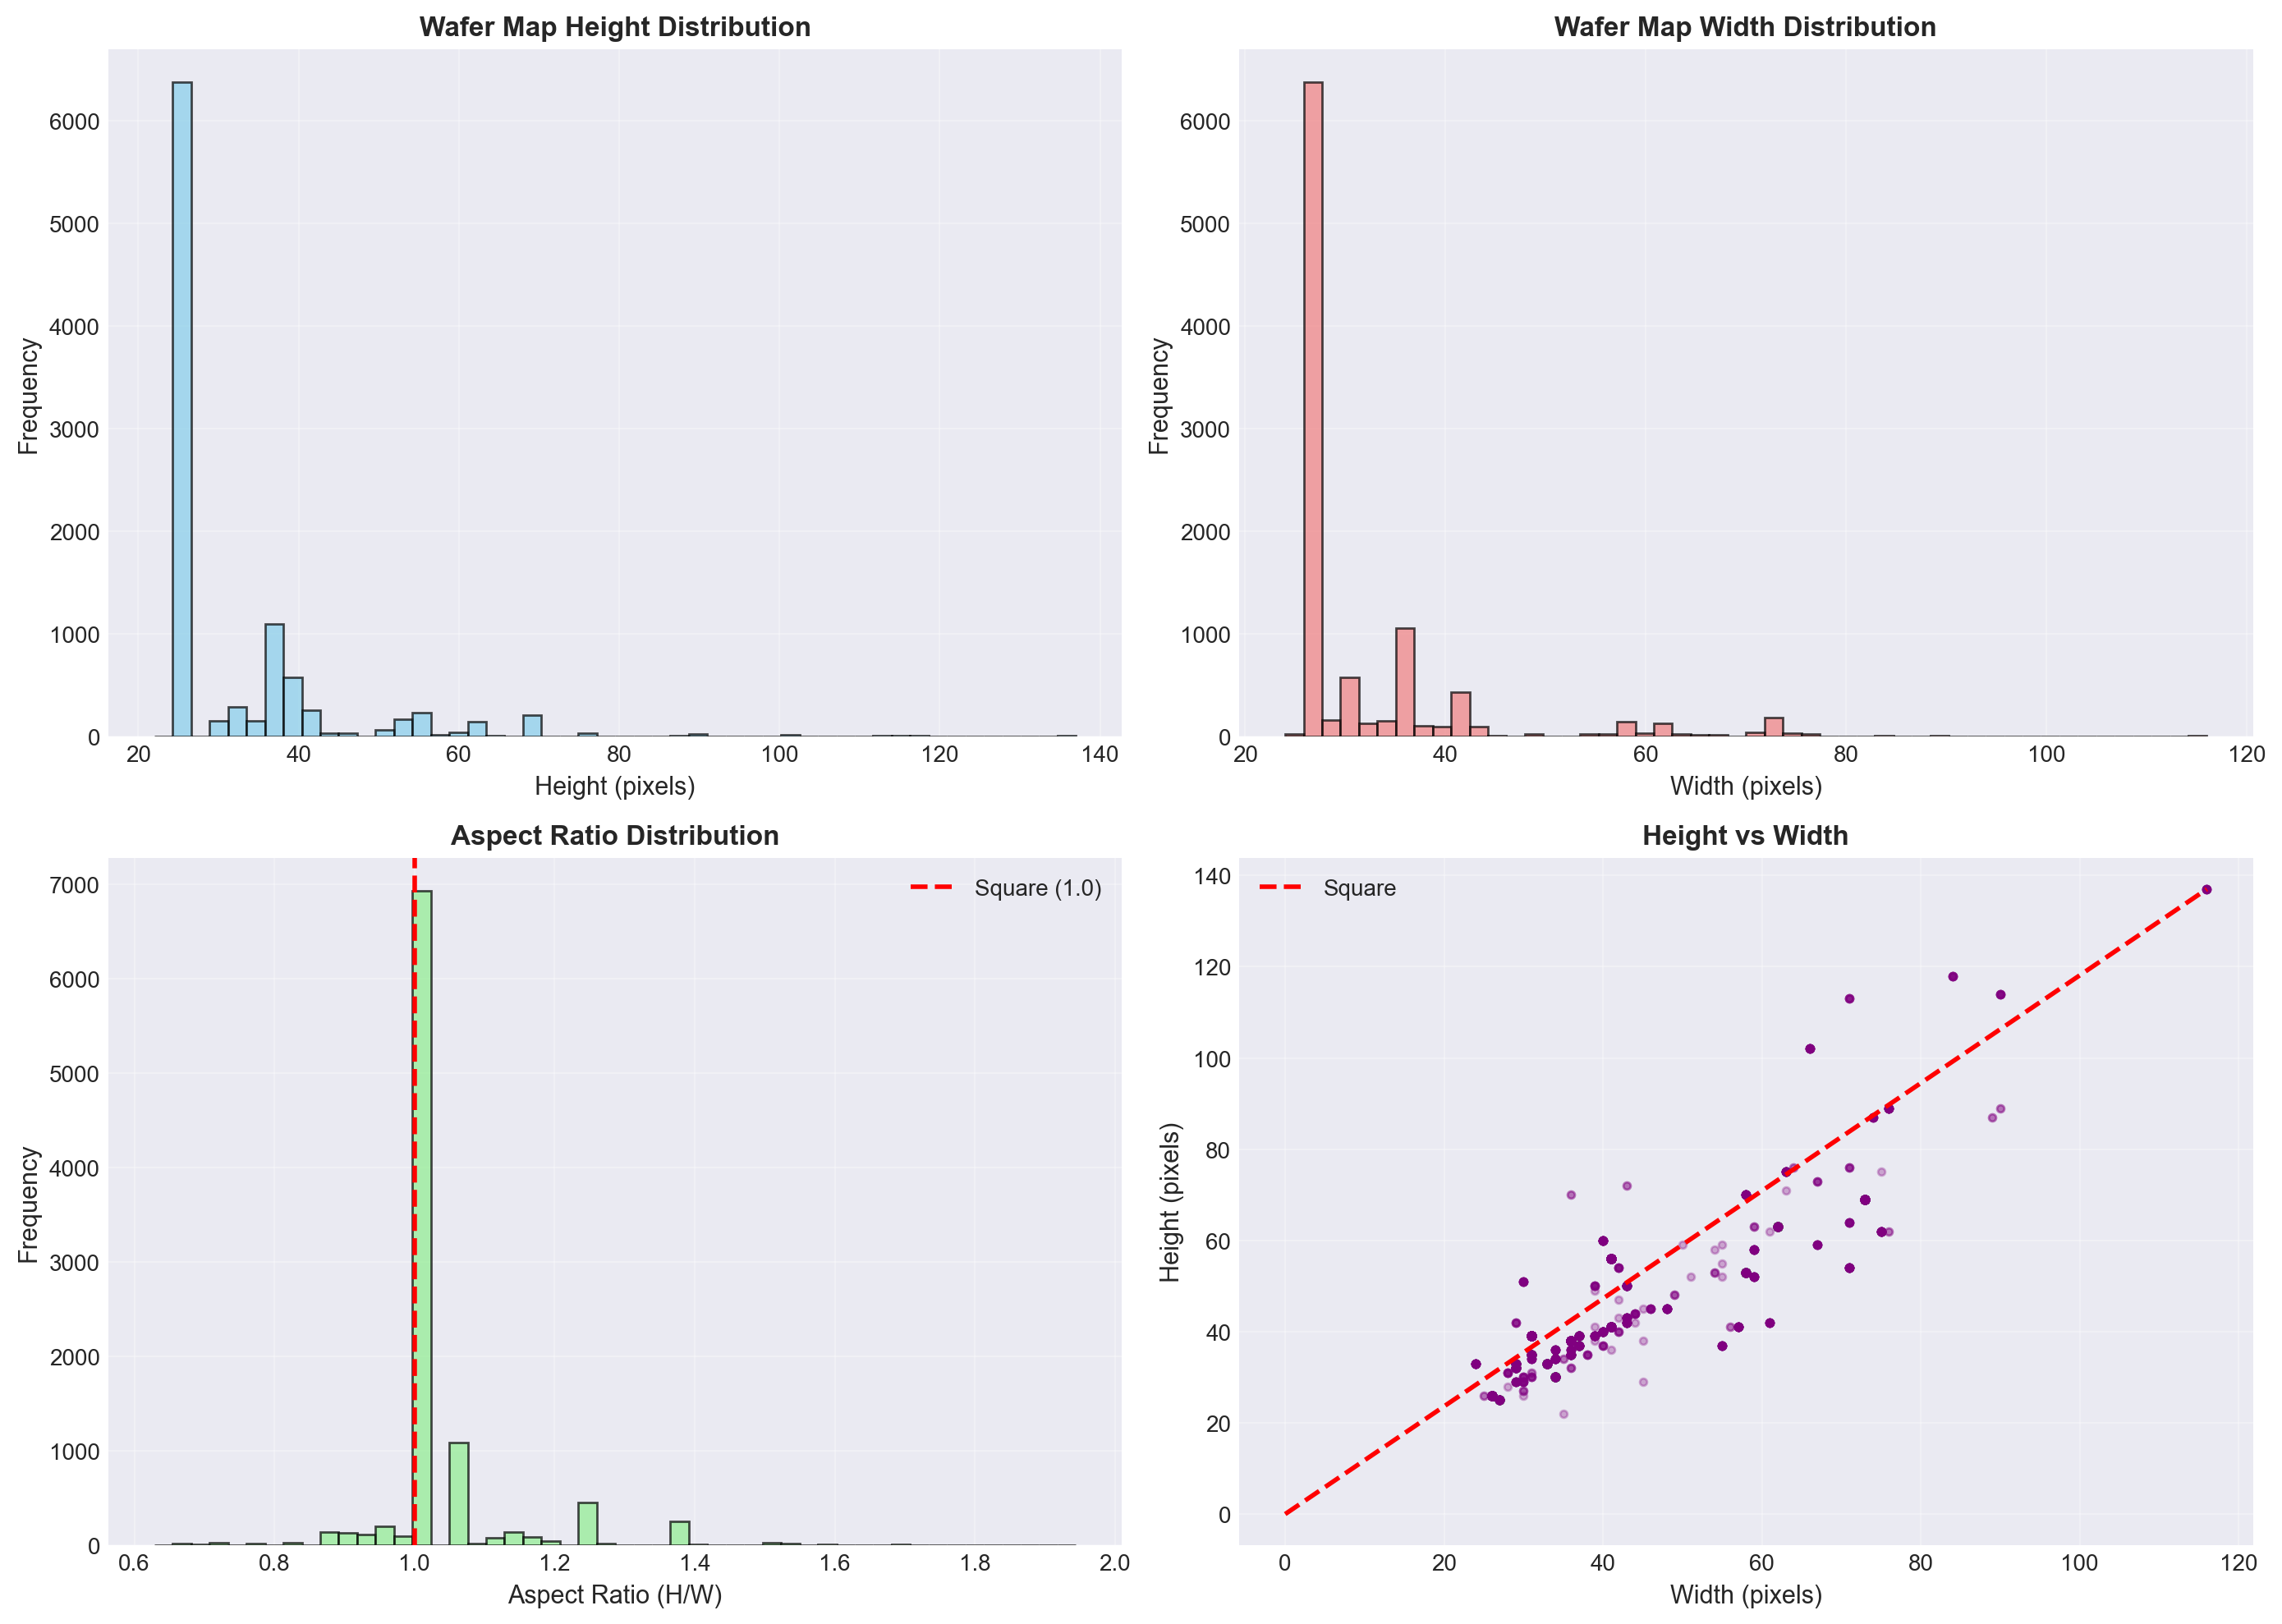

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(wafer_heights, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Height (pixels)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Wafer Map Height Distribution', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(wafer_widths, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Width (pixels)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Wafer Map Width Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].hist(aspect_ratios, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Aspect Ratio (H/W)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Aspect Ratio Distribution', fontsize=12, fontweight='bold')
axes[1, 0].axvline(1.0, color='red', linestyle='--', linewidth=2, label='Square (1.0)')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].scatter(wafer_widths, wafer_heights, alpha=0.3, s=10, color='purple')
axes[1, 1].set_xlabel('Width (pixels)', fontsize=11)
axes[1, 1].set_ylabel('Height (pixels)', fontsize=11)
axes[1, 1].set_title('Height vs Width', fontsize=12, fontweight='bold')
axes[1, 1].plot([0, max(wafer_widths)], [0, max(wafer_heights)], 'r--', linewidth=2, label='Square')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/visualizations/wafer_dimensions.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Visualize Sample Wafer Maps by Defect Type

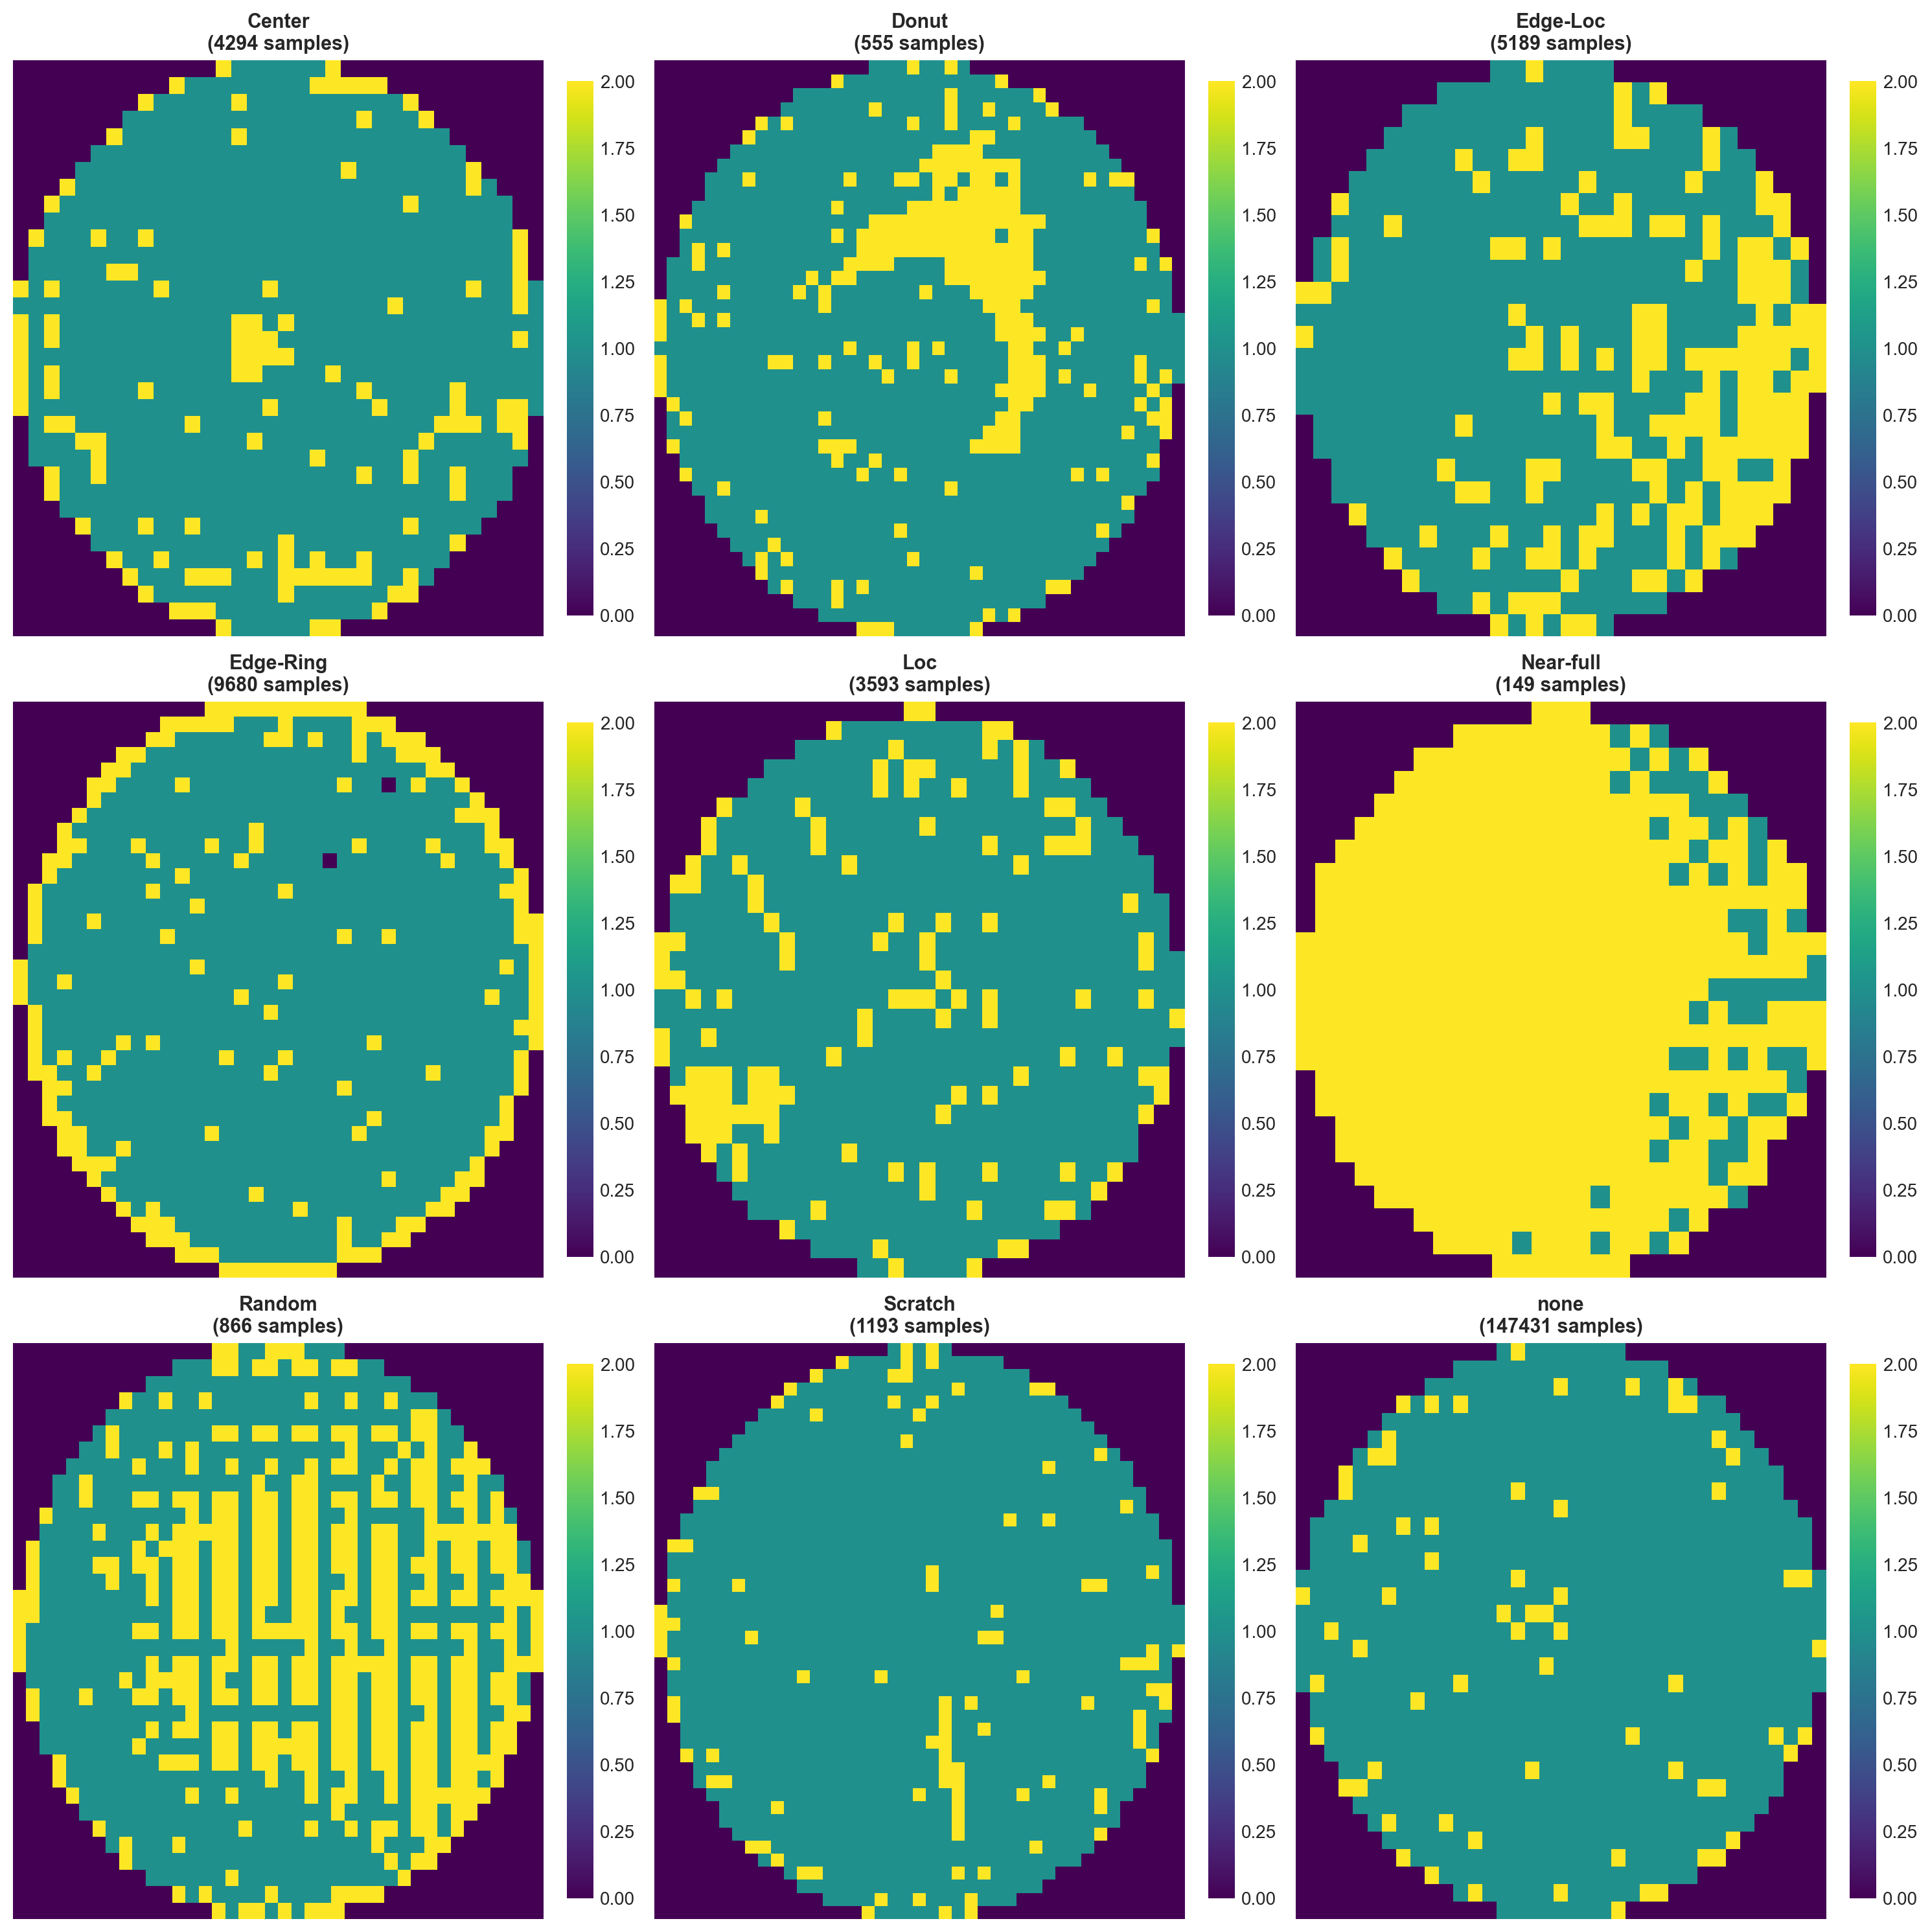

In [17]:
class_names = processor.class_names

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for idx, class_name in enumerate(class_names):
    class_df = df[df['failureType_clean'] == class_name]
    
    if len(class_df) > 0:
        sample_idx = np.random.randint(0, len(class_df))
        wafer_map = np.array(class_df.iloc[sample_idx]['waferMap'])
        
        im = axes[idx].imshow(wafer_map, cmap='viridis', aspect='auto')
        axes[idx].set_title(f'{class_name}\n({len(class_df)} samples)', fontsize=11, fontweight='bold')
        axes[idx].axis('off')
        plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
    else:
        axes[idx].text(0.5, 0.5, 'No samples', ha='center', va='center', fontsize=12)
        axes[idx].set_title(class_name, fontsize=11, fontweight='bold')
        axes[idx].axis('off')

plt.tight_layout()
plt.savefig('../outputs/visualizations/sample_wafer_maps.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Multiple Samples per Defect Class

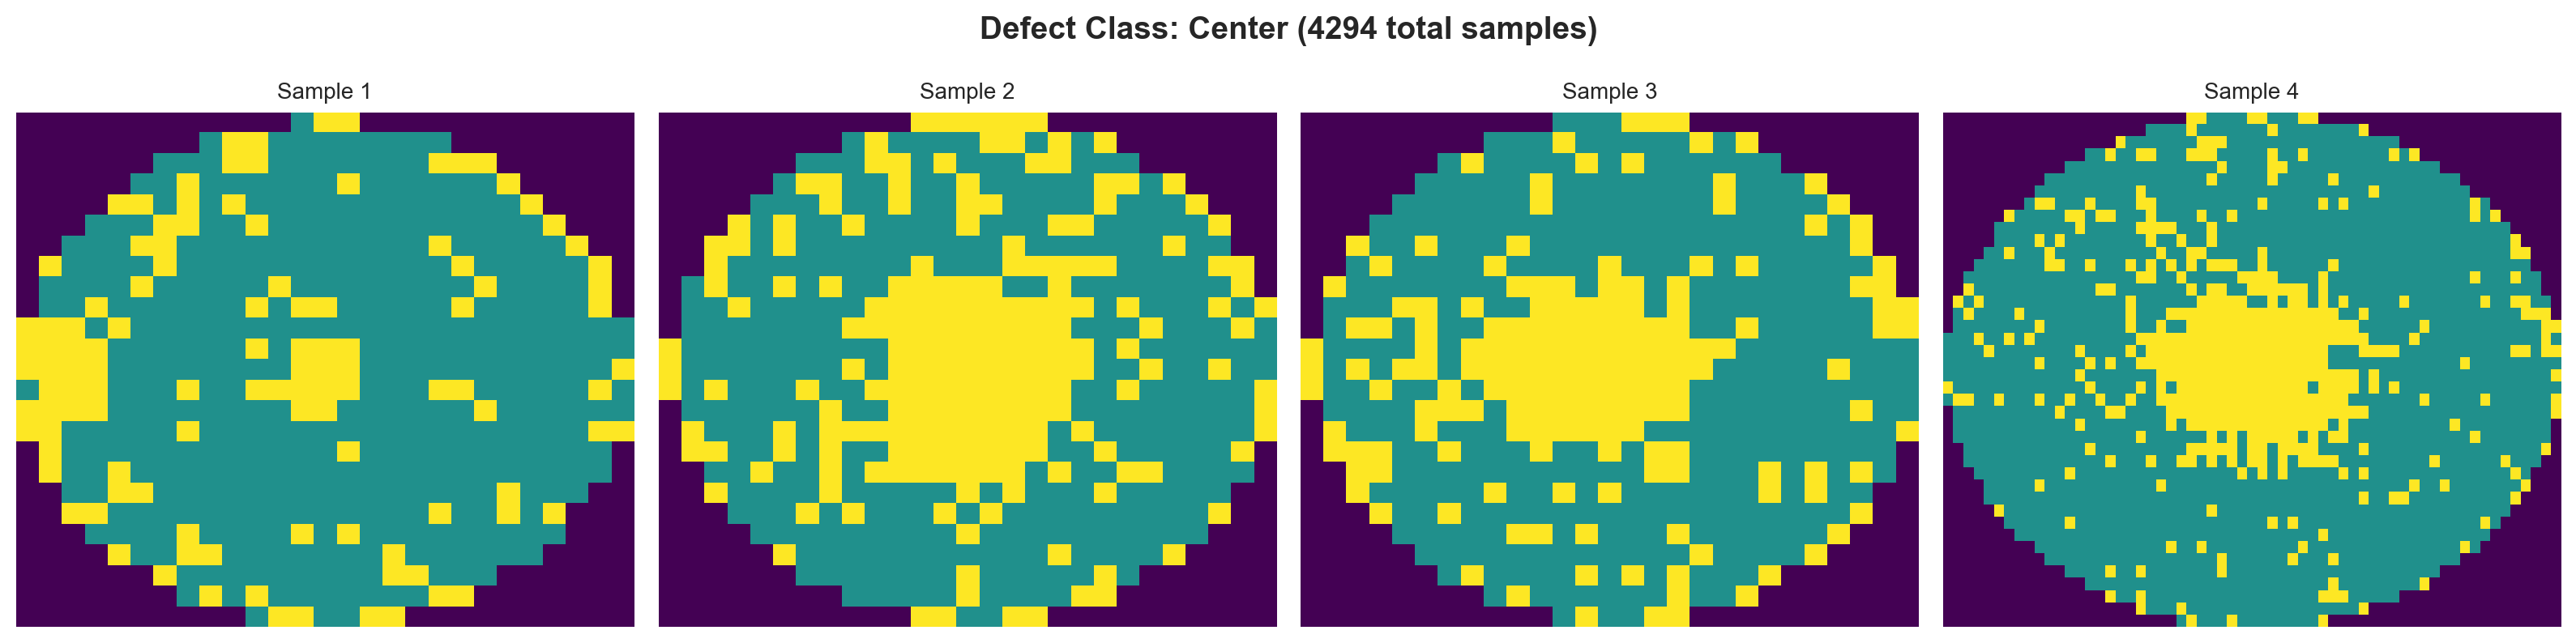

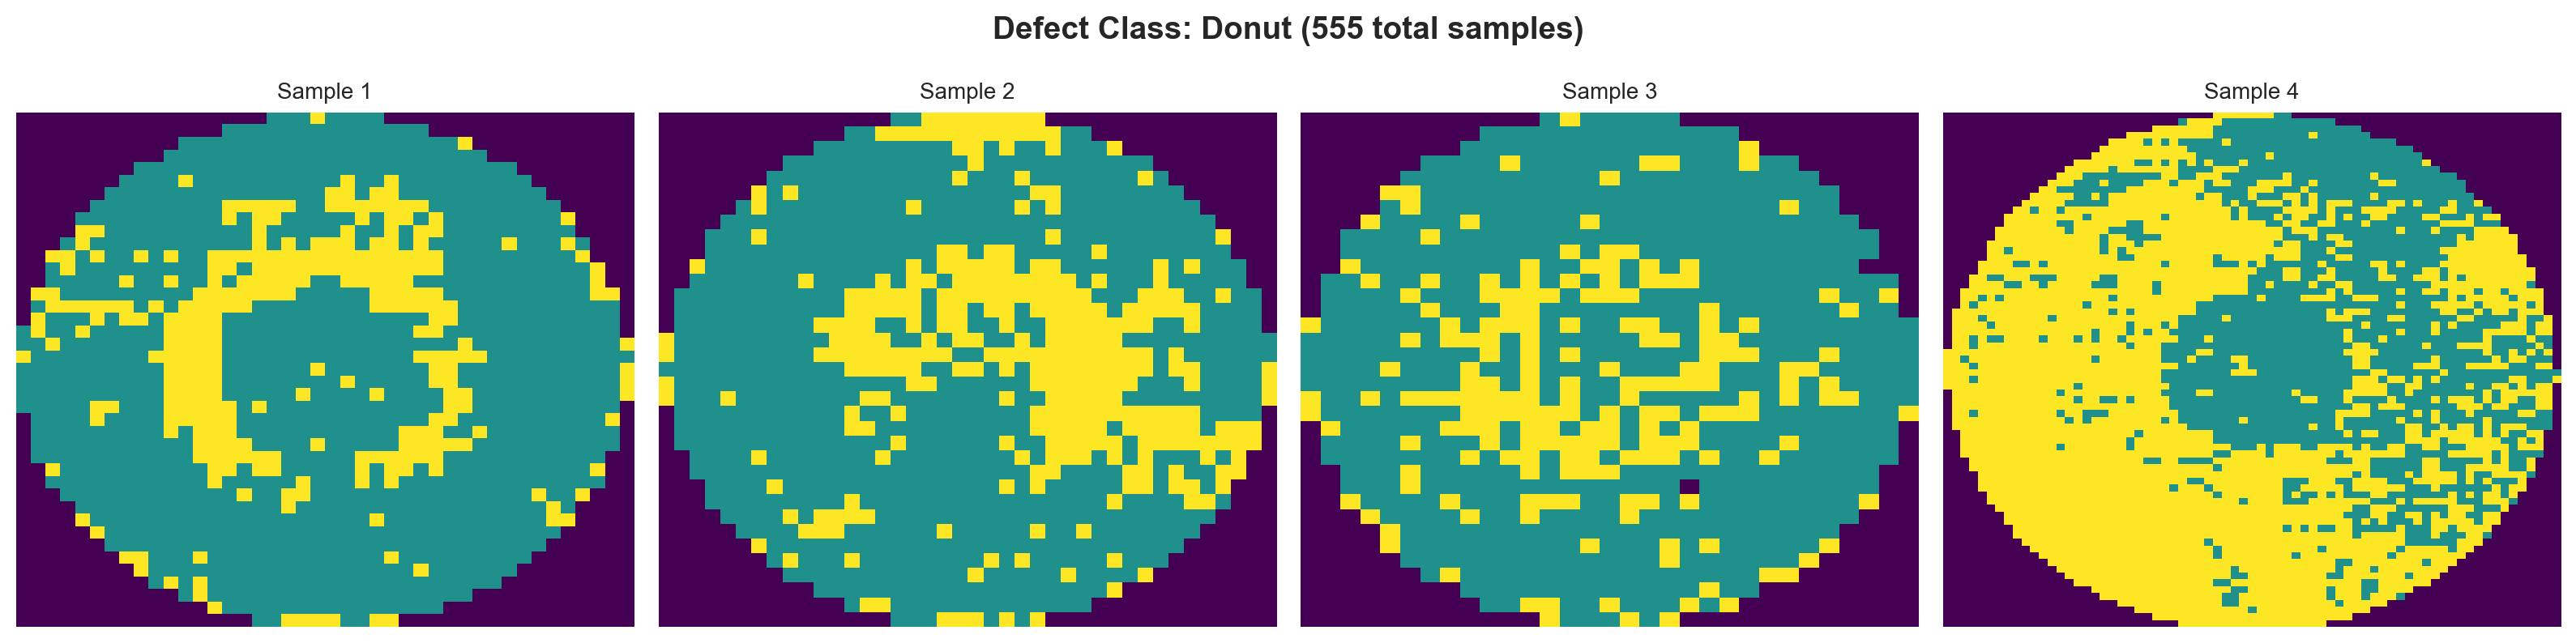

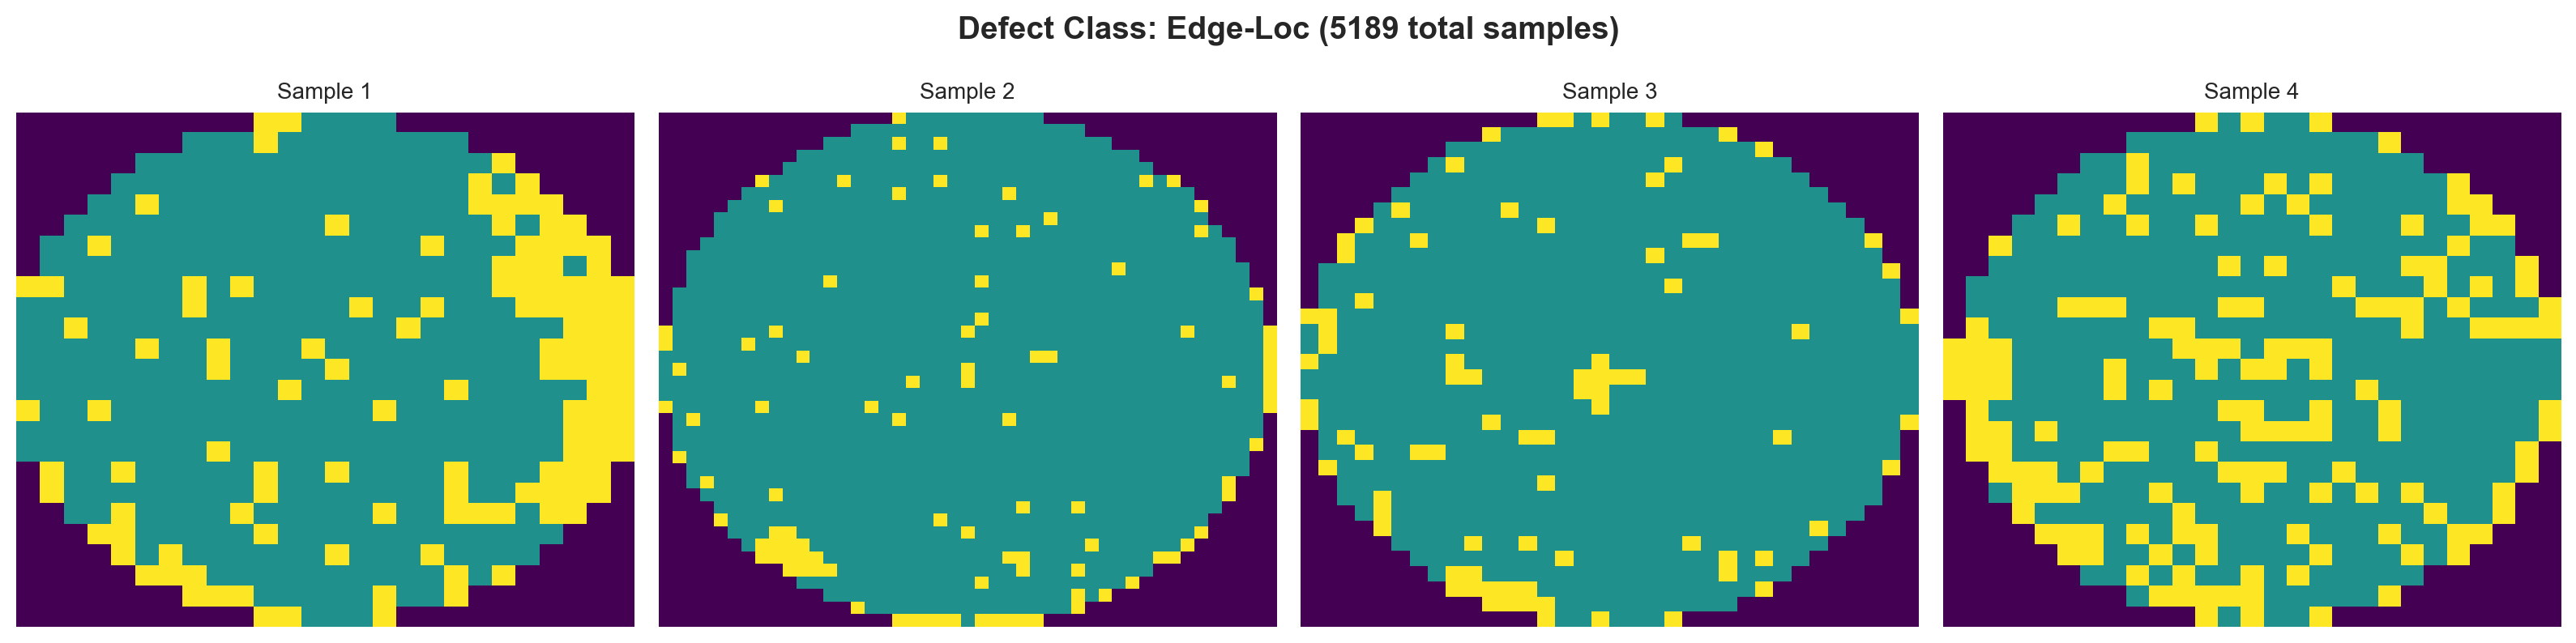

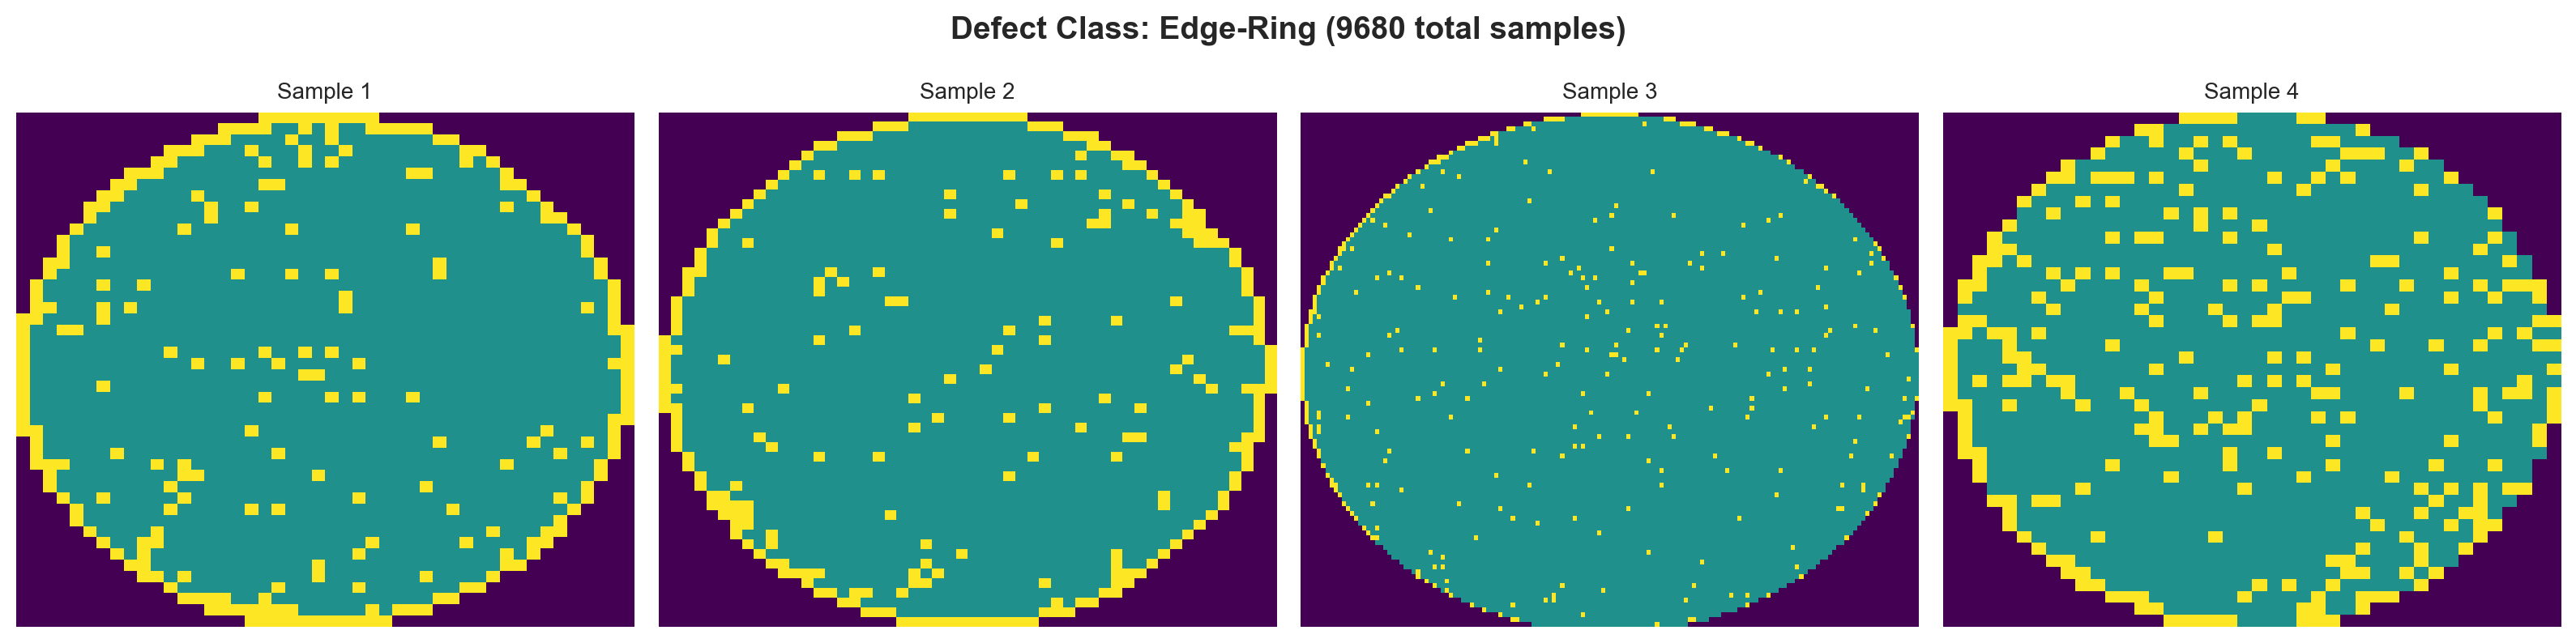

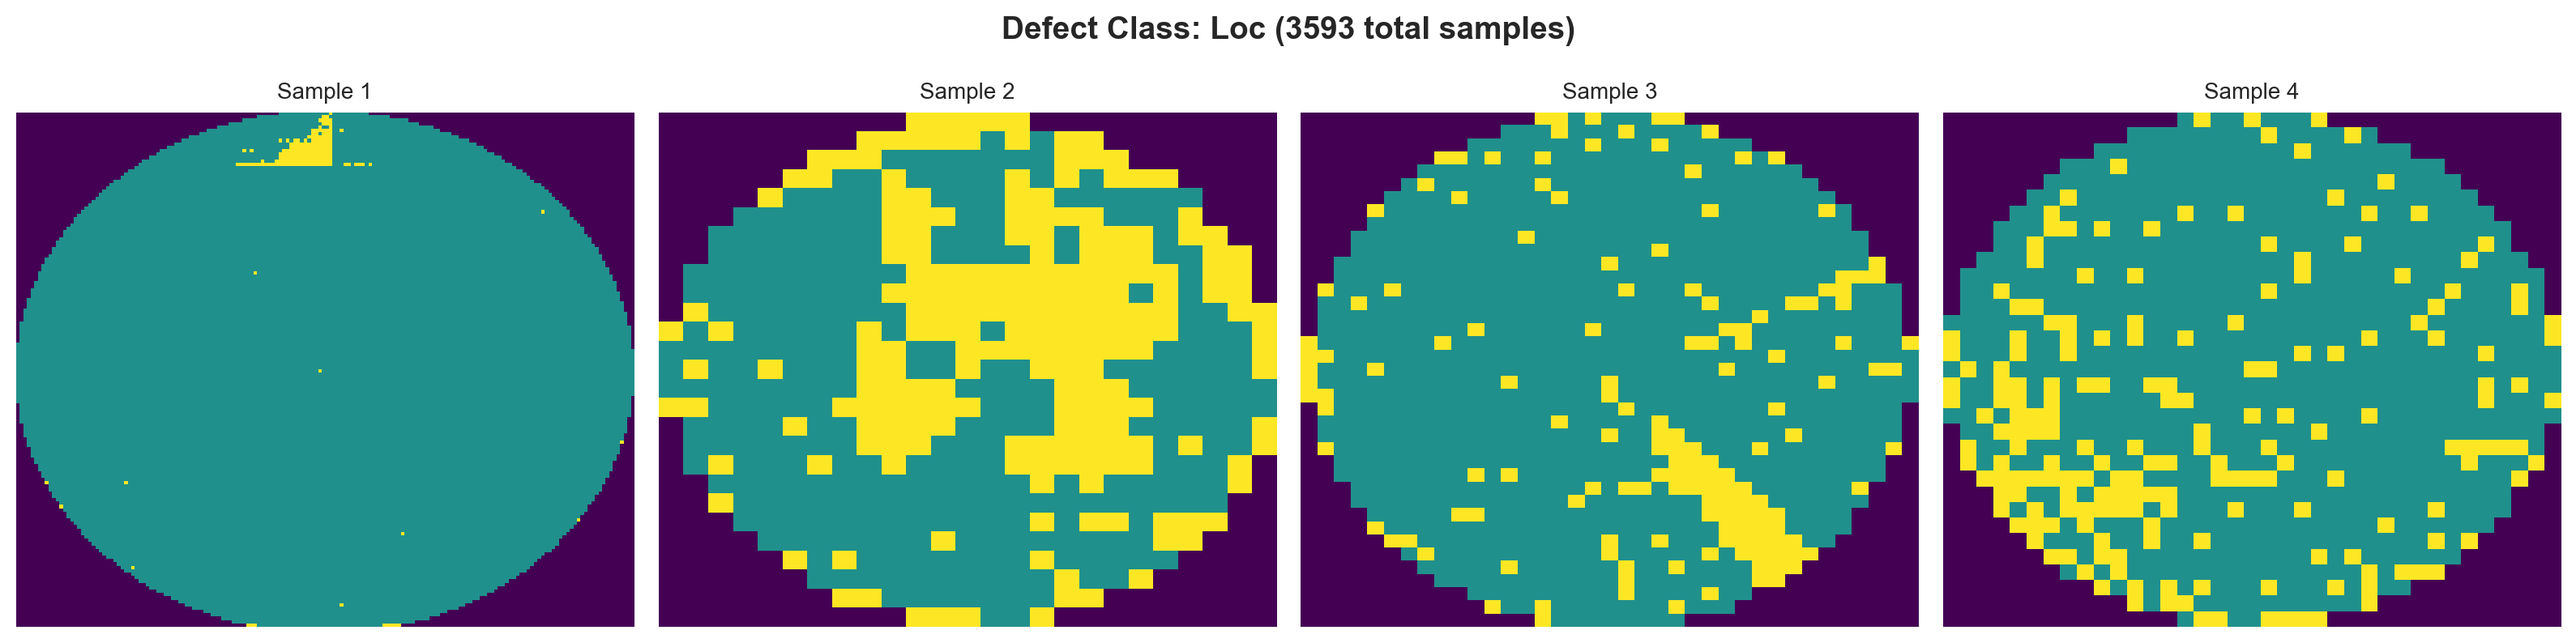

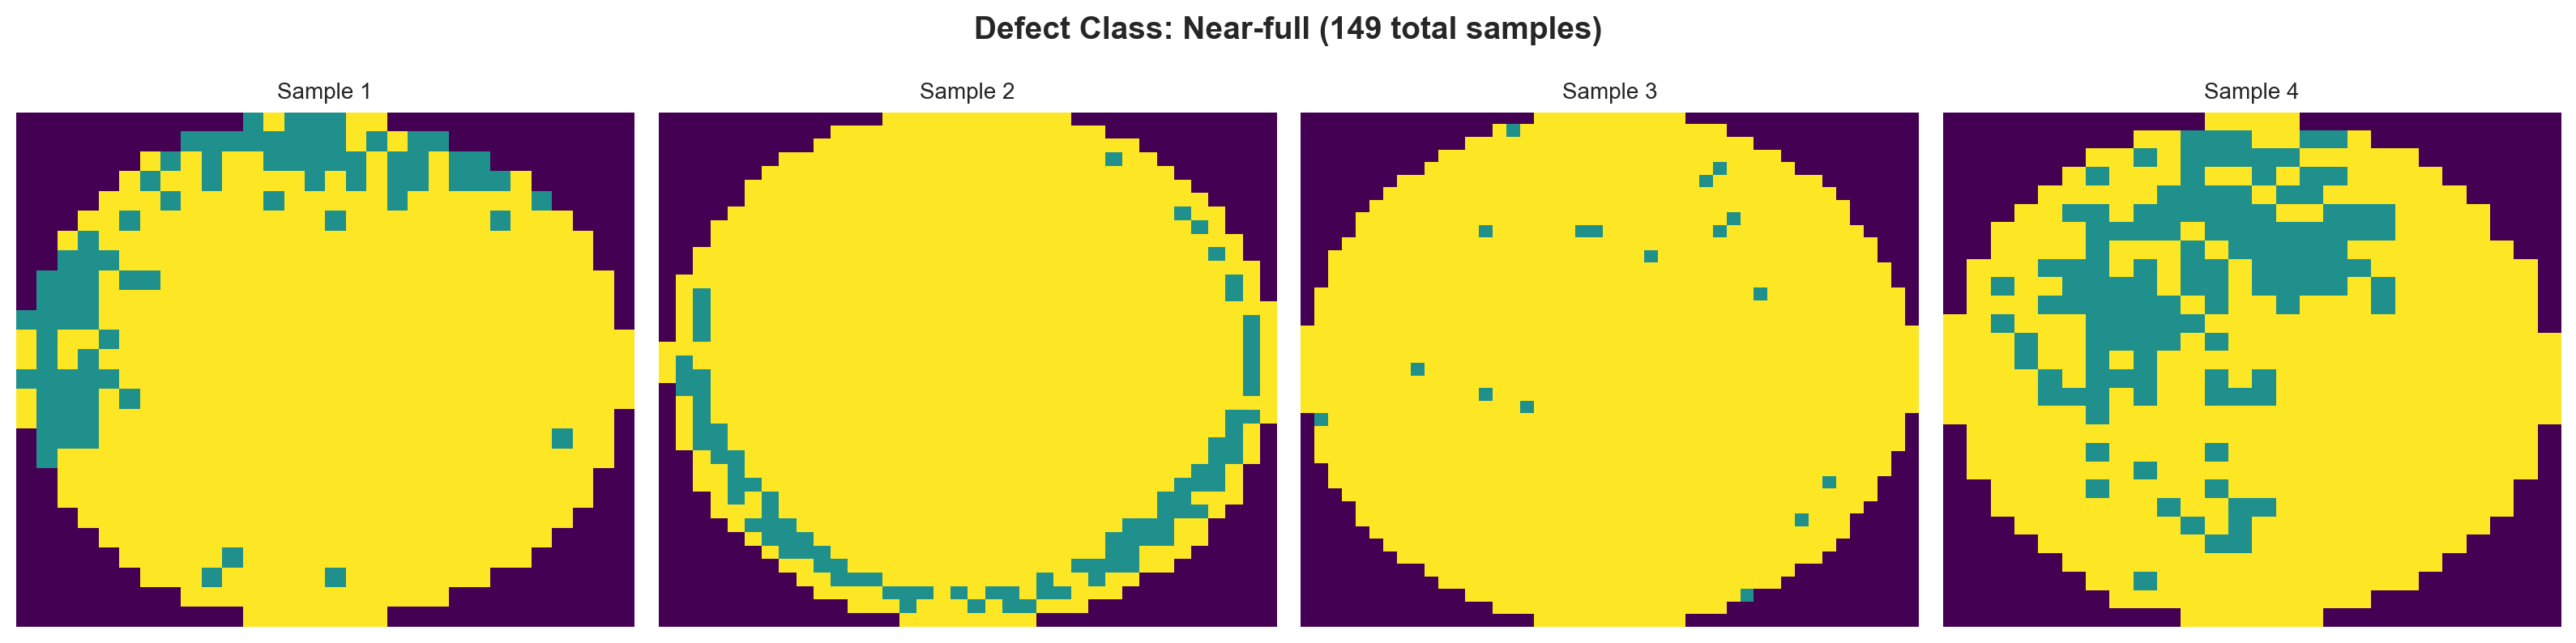

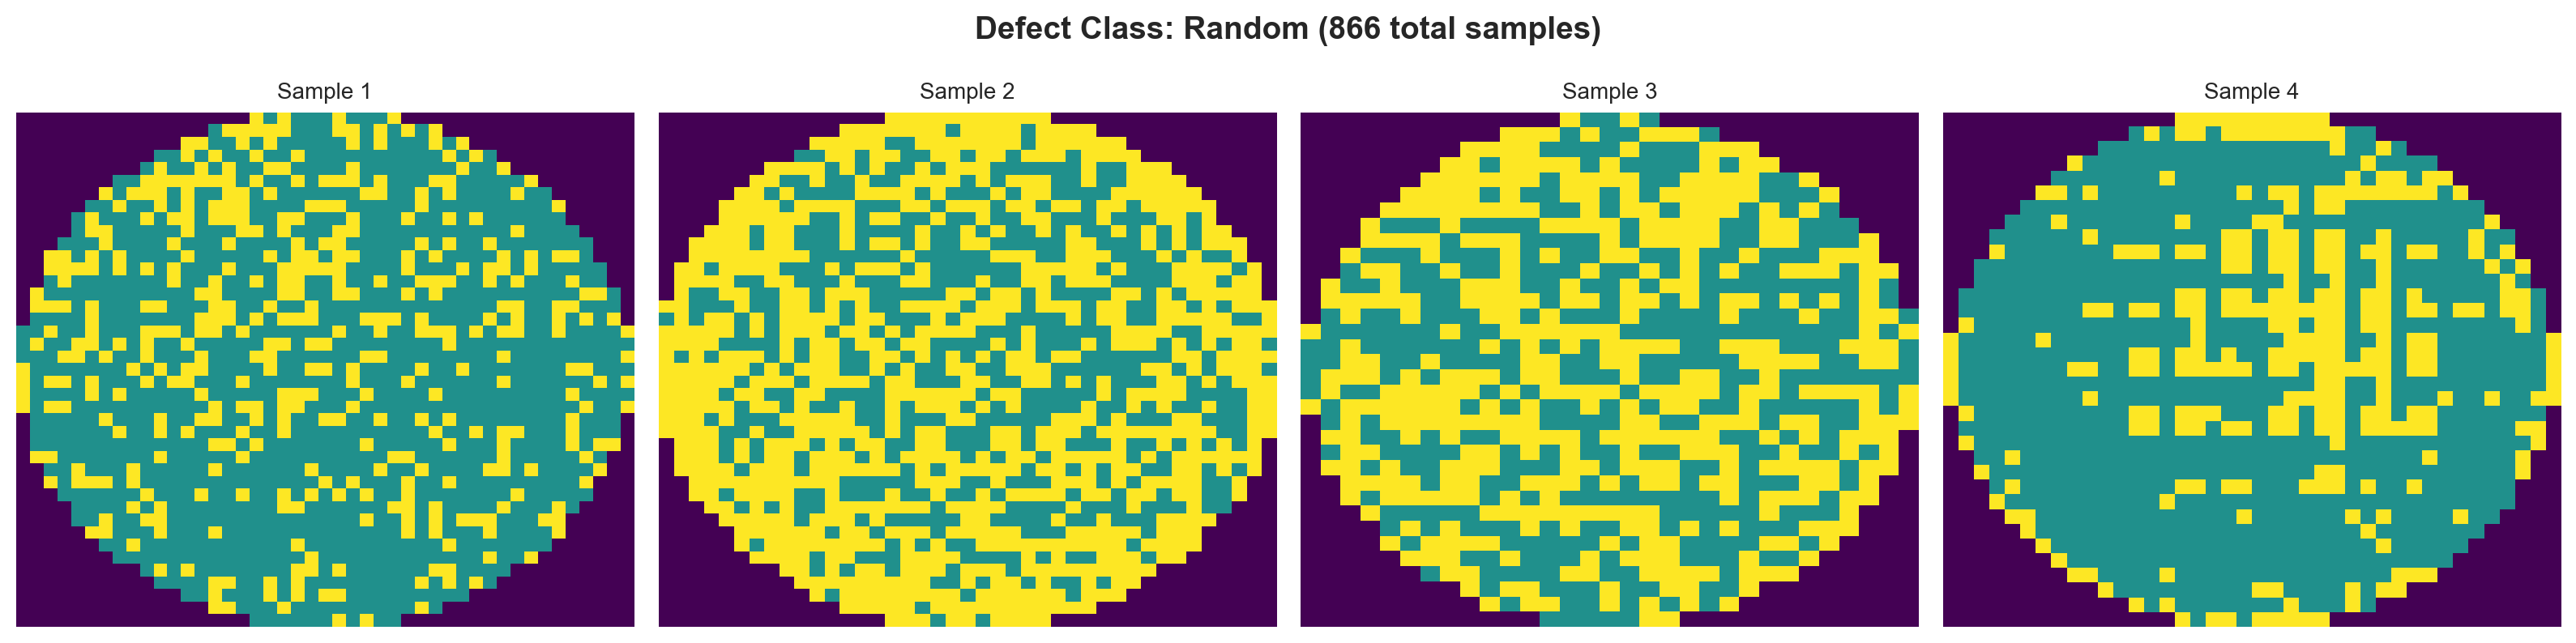

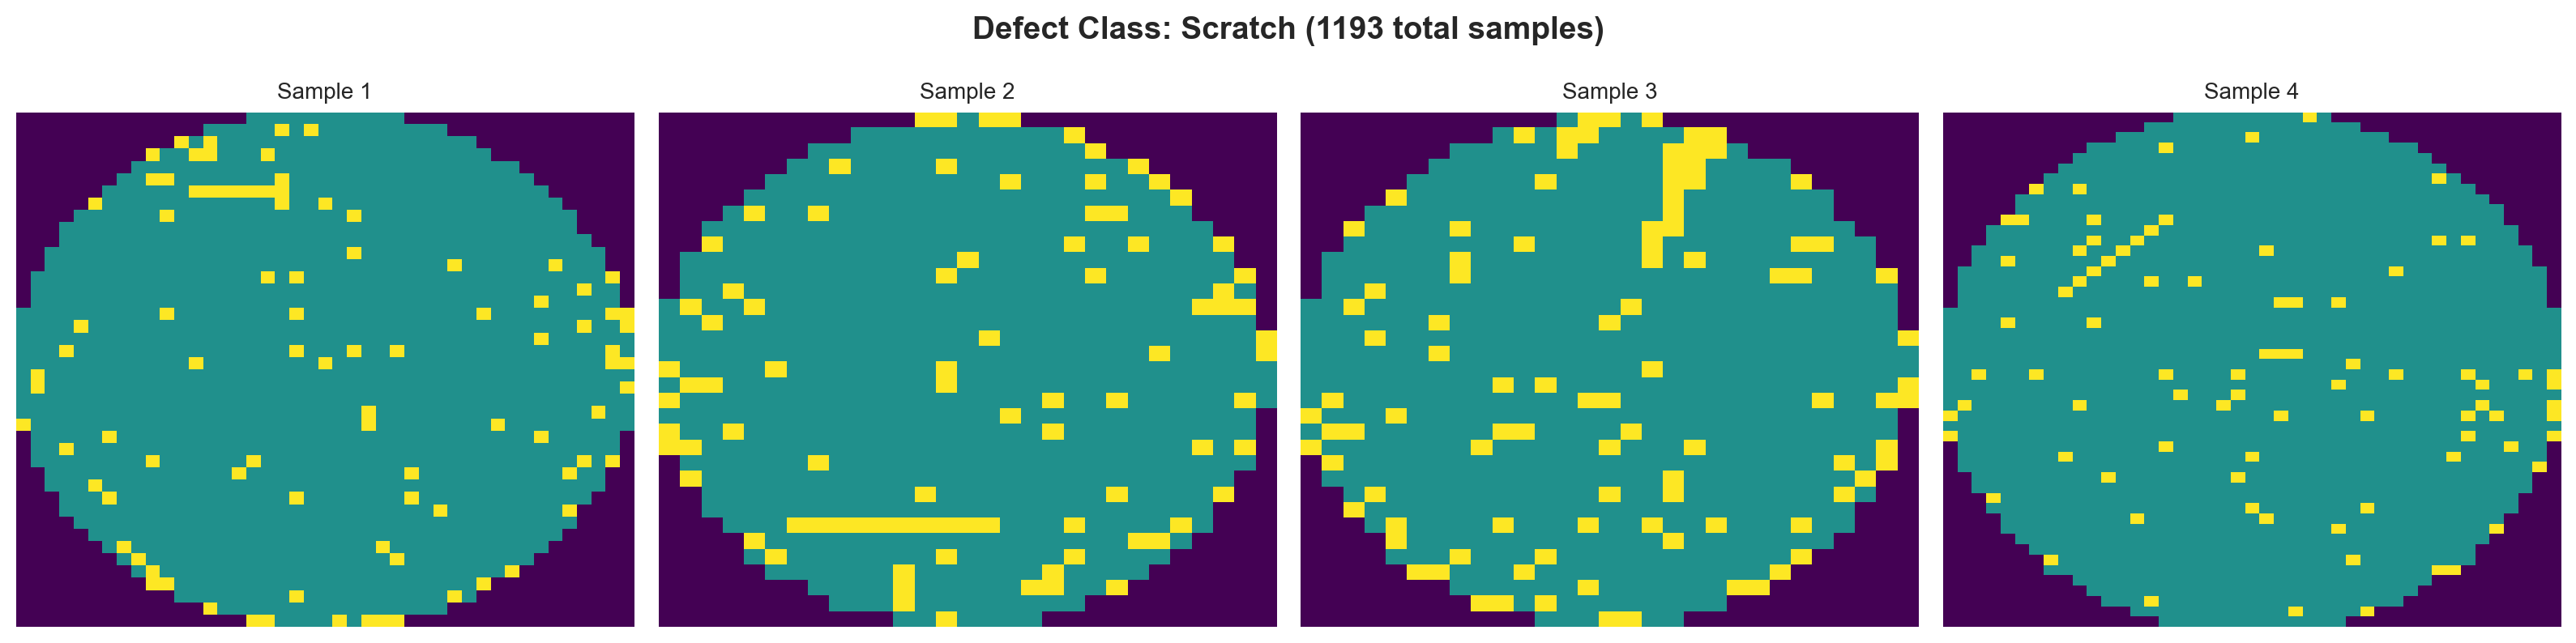

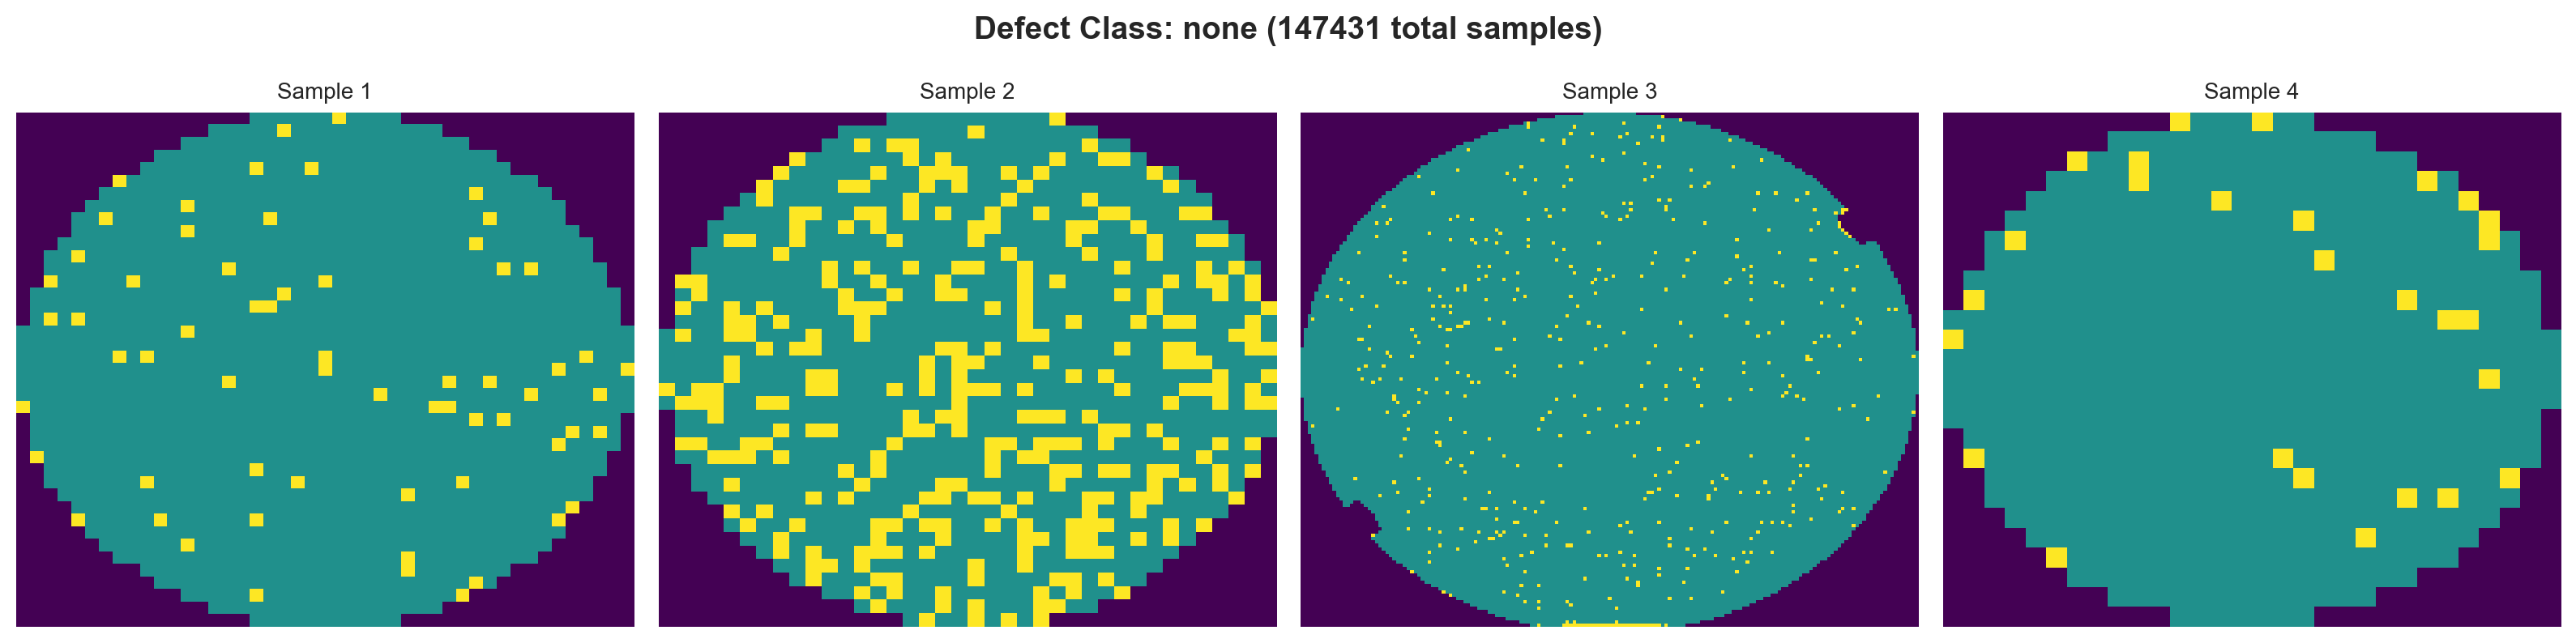

In [18]:
samples_per_class = 4

for class_name in class_names:
    class_df = df[df['failureType_clean'] == class_name]
    
    if len(class_df) >= samples_per_class:
        fig, axes = plt.subplots(1, samples_per_class, figsize=(16, 4))
        
        sample_indices = np.random.choice(len(class_df), samples_per_class, replace=False)
        
        for i, sample_idx in enumerate(sample_indices):
            wafer_map = np.array(class_df.iloc[sample_idx]['waferMap'])
            
            axes[i].imshow(wafer_map, cmap='viridis', aspect='auto')
            axes[i].set_title(f'Sample {i+1}', fontsize=10)
            axes[i].axis('off')
        
        fig.suptitle(f'Defect Class: {class_name} ({len(class_df)} total samples)', 
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'../outputs/visualizations/samples_{class_name}.png', dpi=300, bbox_inches='tight')
        plt.show()

## 6. Die Size Analysis

In [ ]:
die_sizes = df['dieSize'].values

print(f"Die Size Statistics:")
print(f"  Min:    {die_sizes.min()}")
print(f"  Max:    {die_sizes.max()}")
print(f"  Mean:   {die_sizes.mean():.2f}")
print(f"  Median: {np.median(die_sizes):.2f}")
print(f"  Std:    {die_sizes.std():.2f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(die_sizes, bins=50, color='teal', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Die Size', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Die Size Distribution', fontsize=12, fontweight='bold')
axes[0].axvline(die_sizes.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {die_sizes.mean():.0f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

die_size_by_class = df.groupby('failureType_clean')['dieSize'].mean().sort_values()
axes[1].barh(die_size_by_class.index, die_size_by_class.values, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Average Die Size', fontsize=11)
axes[1].set_ylabel('Defect Class', fontsize=11)
axes[1].set_title('Average Die Size by Defect Class', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/visualizations/die_size_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Train/Test Split Analysis

In [ ]:
if 'trianTestLabel' in df.columns:
    split_counts = df['trianTestLabel'].value_counts()
    print("Train/Test Split:")
    print(split_counts)
    print(f"\nPercentages:")
    print(split_counts / len(df) * 100)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    split_counts.plot(kind='bar', ax=ax, color=['steelblue', 'orange'], edgecolor='black', alpha=0.7)
    ax.set_xlabel('Split', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Train/Test Split Distribution', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)
    
    for i, count in enumerate(split_counts):
        ax.text(i, count + max(split_counts)*0.01, str(count), ha='center', va='bottom', fontsize=11)
    
    plt.tight_layout()
    plt.savefig('../outputs/visualizations/train_test_split.png', dpi=300, bbox_inches='tight')
    plt.show()

## 8. Defect Density Analysis

In [ ]:
defect_densities = []
defect_labels = []

for idx in range(min(5000, len(df))):
    wafer_map = np.array(df.iloc[idx]['waferMap'])
    label = df.iloc[idx]['failureType_clean']
    
    if wafer_map.size > 0:
        defect_density = np.sum(wafer_map == 2) / wafer_map.size
        defect_densities.append(defect_density)
        defect_labels.append(label)

density_df = pd.DataFrame({'defect_density': defect_densities, 'class': defect_labels})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(defect_densities, bins=50, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Defect Density', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Overall Defect Density Distribution', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

density_by_class = density_df.groupby('class')['defect_density'].mean().sort_values()
axes[1].barh(density_by_class.index, density_by_class.values, color='salmon', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Average Defect Density', fontsize=11)
axes[1].set_ylabel('Defect Class', fontsize=11)
axes[1].set_title('Average Defect Density by Class', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/visualizations/defect_density.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Summary Statistics

In [ ]:
print("="*60)
print("WAFER DATASET SUMMARY")
print("="*60)
print(f"Total Wafer Maps: {len(df):,}")
print(f"Number of Classes: {len(class_names)}")
print(f"Classes: {', '.join(class_names)}")
print(f"\nMost Common Class: {df['failureType_clean'].value_counts().index[0]} ({df['failureType_clean'].value_counts().values[0]:,} samples)")
print(f"Least Common Class: {df['failureType_clean'].value_counts().index[-1]} ({df['failureType_clean'].value_counts().values[-1]:,} samples)")
print(f"\nClass Imbalance Ratio: {df['failureType_clean'].value_counts().values[0] / df['failureType_clean'].value_counts().values[-1]:.2f}:1")
print(f"\nAverage Wafer Dimensions: {np.mean(wafer_heights):.1f} x {np.mean(wafer_widths):.1f} pixels")
print(f"Average Die Size: {die_sizes.mean():.0f}")
print(f"Average Defect Density: {np.mean(defect_densities):.4f}")
print("="*60)